# 02 — Detection Methods (Phase 4a)

## Setup

Same connection pattern as `01_eda.ipynb` — credentials from `.env`,
jupysql for SQL cells, pandas pulled in only when a cell needs a chart or a
stats/ML routine. Every query below reads from `journal_entry_features`
(the Phase 2 table) or the raw star schema. `ground_truth` is never
queried, joined, or referenced — these are the blind statistical/
unsupervised methods from the Phase plan; scoring against ground truth is
Phase 5, not here.

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

%load_ext sql

In [2]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

user = quote_plus(os.environ["PGUSER"])
password = quote_plus(os.environ["PGPASSWORD"])
conn_str = (
    f"postgresql+psycopg2://{user}:{password}"
    f"@{os.environ['PGHOST']}:{os.environ['PGPORT']}/{os.environ['PGDATABASE']}"
)
engine = create_engine(conn_str)

%sql engine
%config SqlMagic.displaylimit = 20
%config SqlMagic.feedback = False
%config SqlMagic.autopandas = False

## 1. Benford's Law

`leading_digit` is already built in the Phase 2 feature table
(`journal_entry_features.leading_digit`, derived by rescaling
`total_amount` into `[1,10)` and flooring — see `sql/02_features.sql`).
Benford's Law says the leading digit of naturally-occurring financial
amounts follows `P(d) = log10(1 + 1/d)`, not a uniform 1-in-9 — small
leading digits (1, 2) are far more common than large ones (8, 9). Fabricated
or manually-adjusted numbers tend to flatten that curve. Testing the whole
ledger first, then repeating it per account.

`primary_account_key` itself isn't exposed as a column in
`journal_entry_features` — the feature table only surfaces aggregates
built *from* it (`account_entry_seq`, `account_amount_zscore`, ...), not
the key. Segmenting by account needs the key itself, so it's reproduced
here with the exact same "largest line wins" rule Phase 2 uses (`DISTINCT
ON (header_id) ... ORDER BY (debit_amount + credit_amount) DESC, line_num
ASC` — see `primary_account` in `sql/02_features.sql`), pulled once and
reused via pandas merges for the rest of this notebook rather than
re-joining `journal_line` in every query that needs an account label.

In [3]:
%%sql primary_account_rs <<
SELECT DISTINCT ON (l.header_id)
    l.header_id,
    l.account_key AS primary_account_key,
    a.account_id,
    a.account_name
FROM journal_line l
JOIN dim_account a ON a.account_key = l.account_key
ORDER BY l.header_id, (l.debit_amount + l.credit_amount) DESC, l.line_num ASC;

In [4]:
primary_account_df = primary_account_rs.DataFrame()
primary_account_df.head()

,header_id,primary_account_key,account_id,account_name
0,2,22,5400,Marketing Expense
1,3,27,5900,Interest Expense
2,4,8,2000,Accounts Payable
3,6,24,5600,Office Supplies Expense
4,7,20,5200,Rent Expense


In [5]:
%%sql benford_agg_rs <<
SELECT leading_digit, COUNT(*) AS n
FROM journal_entry_features
WHERE leading_digit IS NOT NULL
GROUP BY leading_digit
ORDER BY leading_digit;

n = 113981
chi-square = 292.383, df = 8, p-value = 1.72e-58
mean abs deviation = 0.497 percentage points


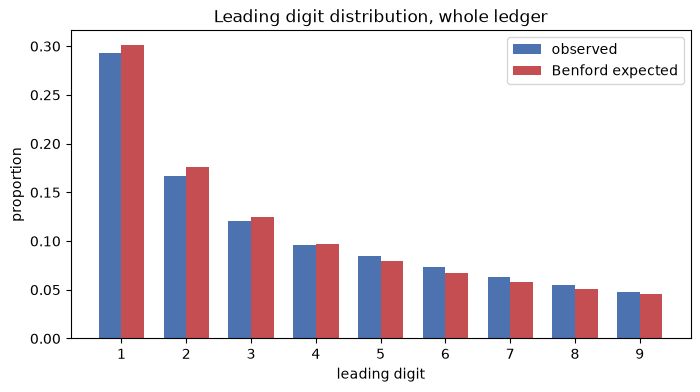

In [6]:
import numpy as np
import pandas as pd
from scipy.stats import chisquare
import matplotlib.pyplot as plt

benford_df = benford_agg_rs.DataFrame().set_index("leading_digit").reindex(range(1, 10), fill_value=0)

digits = np.arange(1, 10)
benford_probs = np.log10(1 + 1 / digits)
n_total = benford_df["n"].sum()
expected = benford_probs * n_total

chi2_stat, p_value = chisquare(f_obs=benford_df["n"].values, f_exp=expected)
mad_agg = np.mean(np.abs(benford_df["n"] / n_total - benford_probs)) * 100

print(f"n = {n_total}")
print(f"chi-square = {chi2_stat:.3f}, df = 8, p-value = {p_value:.4g}")
print(f"mean abs deviation = {mad_agg:.3f} percentage points")

fig, ax = plt.subplots(figsize=(8, 4))
width = 0.35
ax.bar(digits - width / 2, benford_df["n"] / n_total, width, label="observed", color="#4C72B0")
ax.bar(digits + width / 2, benford_probs, width, label="Benford expected", color="#C44E52")
ax.set_xlabel("leading digit")
ax.set_ylabel("proportion")
ax.set_title("Leading digit distribution, whole ledger")
ax.set_xticks(digits)
ax.legend()
plt.show()

### Segmented by account

Same test, run separately for each account's `primary_account_key`. An
account needs a reasonable sample for a chi-square test to mean anything,
so accounts are only tested at `n >= 50` entries — below that, a "failure"
is as likely to be sampling noise as a real deviation. Ranking the tested
accounts by deviation two ways: the chi-square statistic itself (confounded
by `n` — a bigger account inflates chi-square for the same relative
deviation, since df is fixed at 8 for all of them), and a scale-free mean
absolute deviation in percentage points between observed and expected
digit proportions.

In [7]:
%%sql benford_leading_rs <<
SELECT header_id, leading_digit
FROM journal_entry_features
WHERE leading_digit IS NOT NULL;

In [8]:
acct_digit_df = (
    benford_leading_rs.DataFrame()
    .merge(primary_account_df, on="header_id")
    .groupby(["primary_account_key", "account_id", "account_name", "leading_digit"])
    .size()
    .reset_index(name="n")
)

pivot = acct_digit_df.pivot_table(
    index=["primary_account_key", "account_id", "account_name"],
    columns="leading_digit",
    values="n",
    fill_value=0,
).reindex(columns=range(1, 10), fill_value=0)

MIN_N = 50
results = []
for (acct_key, acct_id, acct_name), row in pivot.iterrows():
    n = row.sum()
    if n < MIN_N:
        continue
    observed = row.values
    expected_acct = benford_probs * n
    stat, p = chisquare(f_obs=observed, f_exp=expected_acct)
    mad_pp = np.mean(np.abs(observed / n - benford_probs)) * 100
    results.append({
        "account_id": acct_id,
        "account_name": acct_name,
        "n": int(n),
        "chi2": stat,
        "p_value": p,
        "mad_pct_points": mad_pp,
    })

benford_acct_results = pd.DataFrame(results).sort_values("mad_pct_points", ascending=False)
n_fail = (benford_acct_results["p_value"] < 0.05).sum()
print(f"{len(benford_acct_results)} accounts tested (n >= {MIN_N}); "
      f"{n_fail} fail Benford at p < 0.05")
benford_acct_results

27 accounts tested (n >= 50); 5 fail Benford at p < 0.05


,account_id,account_name,n,chi2,p_value,mad_pct_points
18,5100,Salaries Expense,7482,3375.946782,0.000000e+00,5.838289
9,2200,Payroll Liabilities,309,12.739811,1.211210e-01,2.108384
12,3000,Common Stock,294,17.636437,2.412359e-02,2.081758
4,1300,Prepaid Expenses,296,15.143130,5.642142e-02,2.061372
1,1010,Cash - Payroll,311,13.532558,9.479253e-02,1.919687
8,2100,Accrued Liabilities,231,17.476707,2.551073e-02,1.835099
13,3100,Retained Earnings,297,8.506626,3.856072e-01,1.796791
5,1500,Fixed Assets,261,14.197974,7.674901e-02,1.696275
11,2400,Notes Payable,250,6.434337,5.986998e-01,1.619707
14,4000,Product Revenue,408,13.299548,1.019503e-01,1.416317


**Finding — not quite the contrast expected, but a sharper one.** The
aggregate test technically *fails*: chi-square = 292.4, p < 0.0001. At
n = 113,981, chi-square is powerful enough to flag almost any nonzero
deviation as "significant" — the effect size (mean absolute deviation,
0.50 percentage points from the expected curve) says the ledger as a whole
is, in practical terms, indistinguishable from Benford. That gap between
p-value and effect size is the first real finding: at this sample size,
p < 0.05 alone is close to meaningless, which is exactly why
`mad_pct_points` was computed alongside `chi2`/`p_value` for the
per-account breakdown.

Reading the account table through that lens: 5 of 27 tested accounts hit
p < 0.05, but their effect sizes tell two different stories. **Accounts
Payable** (n = 26,324) is "significant" (p = 7.4e-8) with a MAD of only
0.38pp — barely different from the aggregate's 0.50pp, and significant for
the same reason the aggregate technically is: a very large n makes small
deviations statistically detectable. Common Stock, Accrued Liabilities,
Prepaid Expenses, and Cash - Payroll all sit near p ≈ 0.05 on n in the
low 300s — plausibly 4-5 false positives among 27 tests at α = 0.05, not
evidence of anything.

**Salaries Expense** is the outlier that matters: MAD = 5.84 percentage
points — nearly 12x the aggregate and more than double the next-highest
account — on n = 7,482, an order of magnitude *fewer* entries than
Accounts Payable. A deviation that large, on a sample that comparatively
small, isn't a large-n artifact; it's a genuinely different digit
distribution, most likely payroll amounts clustering in a narrow band
(fixed salary tiers, not organically log-normal transaction amounts) that
Benford's Law was never going to fit well in the first place. That's the
real version of the contrast this section set out to find: a flat,
ledger-wide pass/fail hides both the aggregate's statistical fragility and
the one account where the deviation is actually large.

## 2. Segmented outliers: z-score and IQR

Two classic univariate outlier rules, both computed **within account**
rather than across the whole ledger — a $50k entry is routine for Cash
Operating and an outlier for a small expense account, so a single global
threshold would just rediscover which accounts run bigger, not which
entries are unusual for their own account.

For z-score, reusing `account_amount_zscore` straight from the Phase 2
feature table rather than recomputing it: it's already an **expanding**
window ordered by `posting_datetime` (no test-period leakage into
train-period figures, see `sql/02_features.sql`) and already NULL below
`account_entry_seq > 10` — a mean/stddev from a handful of points isn't a
real baseline. This notebook keeps that same `account_entry_seq > 10` gate
throughout Section 2–4 (referred to below as the "scored population") so
z-score, IQR, and Isolation Forest are all judged against an identical set
of rows — otherwise a difference in flag counts could just be a difference
in which rows each method was even allowed to see.

IQR doesn't have a running-window equivalent readily available in Postgres
(no window-function form of `PERCENTILE_CONT`), so account-level Q1/Q3 are
computed as a plain per-account aggregate — but restricted to the same
scored population, so it's not drawing on more information than the
z-score gets. Same `primary_account` re-derivation as the Benford section
above, inlined as a CTE here since this query needs to `GROUP BY` on it
directly rather than merge it on in pandas.

Both are computed twice: segmented (within account) and global
(unsegmented, same scored population) — to see what segmentation actually
buys over one ledger-wide threshold.

In [9]:
%%sql seg_outlier_rs <<
WITH primary_account AS (
    SELECT DISTINCT ON (header_id) header_id, account_key AS primary_account_key
    FROM journal_line
    ORDER BY header_id, (debit_amount + credit_amount) DESC, line_num ASC
),
eligible AS (
    SELECT f.header_id, pa.primary_account_key, f.total_amount, f.account_amount_zscore
    FROM journal_entry_features f
    JOIN primary_account pa ON pa.header_id = f.header_id
    WHERE f.account_entry_seq > 10
),
acct_stats AS (
    SELECT
        primary_account_key,
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY total_amount) AS q1,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY total_amount) AS q3
    FROM eligible
    GROUP BY primary_account_key
),
global_stats AS (
    SELECT
        AVG(total_amount)    AS g_mean,
        STDDEV(total_amount) AS g_std,
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY total_amount) AS g_q1,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY total_amount) AS g_q3
    FROM eligible
)
SELECT
    e.header_id,
    e.primary_account_key,
    e.total_amount,
    e.account_amount_zscore,
    (e.total_amount - g.g_mean) / NULLIF(g.g_std, 0) AS global_zscore,
    s.q1, s.q3,
    g.g_q1, g.g_q3
FROM eligible e
JOIN acct_stats s   ON s.primary_account_key = e.primary_account_key
CROSS JOIN global_stats g;

In [10]:
outlier_df = seg_outlier_rs.DataFrame()

outlier_df["seg_iqr"] = outlier_df["q3"] - outlier_df["q1"]
outlier_df["glob_iqr"] = outlier_df["g_q3"] - outlier_df["g_q1"]

outlier_df["seg_z_flag"] = outlier_df["account_amount_zscore"].abs() > 3
outlier_df["glob_z_flag"] = outlier_df["global_zscore"].abs() > 3
outlier_df["seg_iqr_flag"] = (
    (outlier_df["total_amount"] < outlier_df["q1"] - 1.5 * outlier_df["seg_iqr"])
    | (outlier_df["total_amount"] > outlier_df["q3"] + 1.5 * outlier_df["seg_iqr"])
)
outlier_df["glob_iqr_flag"] = (
    (outlier_df["total_amount"] < outlier_df["g_q1"] - 1.5 * outlier_df["glob_iqr"])
    | (outlier_df["total_amount"] > outlier_df["g_q3"] + 1.5 * outlier_df["glob_iqr"])
)

print(f"scored population: {len(outlier_df)} entries\n")
print("z-score: segmented flags", outlier_df["seg_z_flag"].sum(),
      "| global flags", outlier_df["glob_z_flag"].sum())
print("IQR:     segmented flags", outlier_df["seg_iqr_flag"].sum(),
      "| global flags", outlier_df["glob_iqr_flag"].sum())

scored population: 113711 entries

z-score: segmented flags 1311 | global flags 810
IQR:     segmented flags 10816 | global flags 15661


In [11]:
def agreement_table(seg_flag, glob_flag, label):
    tbl = pd.crosstab(
        pd.Series(seg_flag, name=f"segmented {label}"),
        pd.Series(glob_flag, name=f"global {label}"),
    )
    both = (seg_flag & glob_flag).sum()
    seg_only = (seg_flag & ~glob_flag).sum()
    glob_only = (~seg_flag & glob_flag).sum()
    print(f"--- {label} ---")
    print(tbl)
    print(f"agree (both flag): {both}  |  segmented-only: {seg_only}  |  global-only: {glob_only}\n")

agreement_table(outlier_df["seg_z_flag"], outlier_df["glob_z_flag"], "z-score")
agreement_table(outlier_df["seg_iqr_flag"], outlier_df["glob_iqr_flag"], "IQR")

--- z-score ---
global z-score      False  True 
segmented z-score               
False              112262    138
True                  639    672
agree (both flag): 672  |  segmented-only: 639  |  global-only: 138

--- IQR ---
global IQR     False  True 
segmented IQR              
False          95101   7794
True            2949   7867
agree (both flag): 7867  |  segmented-only: 2949  |  global-only: 7794



**Where they disagree** is the interesting part. A "segmented-only" flag
is an entry that's routine ledger-wide but unusual for its own account —
exactly the case segmentation is supposed to catch. A "global-only" flag is
usually just an entry in a naturally high-amount account (Cash, Payroll)
that a whole-ledger threshold can't help but flag, even though it's normal
for that account — segmentation's main failure mode in reverse. Carrying
`seg_z_flag OR seg_iqr_flag` forward as this section's one entry-level
output, `segmented_outlier_flag`, for the method-overlap comparison in
Section 4.

In [12]:
outlier_df["segmented_outlier_flag"] = outlier_df["seg_z_flag"] | outlier_df["seg_iqr_flag"]
print("segmented_outlier_flag:", outlier_df["segmented_outlier_flag"].sum(), "entries")

segmented_outlier_flag: 10817 entries


## 3. Isolation Forest

Multivariate anomaly detection over the numeric feature matrix — catches
the joint pattern a univariate rule can't (e.g. a normal amount posted by
an employee brand-new to that account, after hours, at period end). Pulling
the same scored population as Section 2 (`account_entry_seq > 10`) so the
three methods stay comparable in Section 4, and only actual model-input
columns from the feature table — `total_amount` itself is left out in
favor of `log_amount`, which is what Phase 4b's supervised models will
also use, and no `ground_truth` column exists in this table to begin with.

**Contamination.** Set to `0.03`, matching the ~3% seeded-error rate that
CLAUDE.md documents as the *data generation design target* for this
dataset (`sql/generate_journal_entries.py`'s intent, not a row-level label
— `ground_truth` itself is never read here). It's the same kind of
population-level base rate a real fraud analyst would use to size a
contamination parameter — last year's known incident rate, not this
year's individual case labels.

In [13]:
%%sql if_features_rs <<
SELECT
    header_id,
    log_amount,
    entry_line_count,
    description_length,
    post_lag_days,
    days_from_period_end,
    account_entry_seq,
    employee_entry_seq,
    user_account_frequency,
    user_entry_count_month,
    account_pair_frequency,
    pct_of_account_monthly_total,
    account_amount_zscore,
    is_round_100::int      AS is_round_100,
    is_round_1000::int     AS is_round_1000,
    is_round_10000::int    AS is_round_10000,
    is_period_end::int  AS is_period_end,
    is_after_hours::int    AS is_after_hours,
    is_weekend::int        AS is_weekend,
    is_manual_entry::int   AS is_manual_entry,
    is_first_time_pair::int AS is_first_time_pair,
    has_description::int   AS has_description
FROM journal_entry_features
WHERE account_entry_seq > 10;

In [14]:
from sklearn.ensemble import IsolationForest

if_df = if_features_rs.DataFrame().set_index("header_id")
print("nulls per column:\n", if_df.isna().sum()[if_df.isna().sum() > 0])

X = if_df.values

iso_forest = IsolationForest(n_estimators=200, contamination=0.03, random_state=42, n_jobs=-1)
iso_forest.fit(X)

if_df["anomaly_score"] = -iso_forest.decision_function(X)
if_df["isolation_forest_flag"] = iso_forest.predict(X) == -1

print(f"\nflagged: {if_df['isolation_forest_flag'].sum()} of {len(if_df)} "
      f"({100 * if_df['isolation_forest_flag'].mean():.2f}%)")

nulls per column:
 Series([], dtype: int64)



flagged: 3412 of 113711 (3.00%)


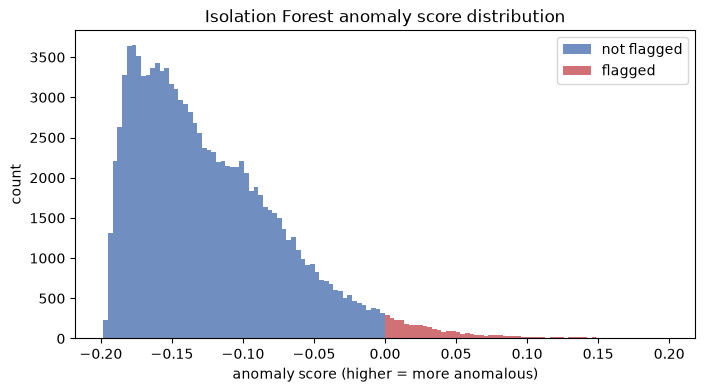

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(if_df.loc[~if_df["isolation_forest_flag"], "anomaly_score"], bins=60,
        color="#4C72B0", label="not flagged", alpha=0.8)
ax.hist(if_df.loc[if_df["isolation_forest_flag"], "anomaly_score"], bins=60,
        color="#C44E52", label="flagged", alpha=0.8)
ax.set_xlabel("anomaly score (higher = more anomalous)")
ax.set_ylabel("count")
ax.set_title("Isolation Forest anomaly score distribution")
ax.legend()
plt.show()

### Explaining the top flags with SHAP

`shap.TreeExplainer` supports `IsolationForest` directly. One thing worth
being explicit about: it explains the model's **raw average path length**,
not `decision_function` — and path length runs the opposite direction from
the anomaly score above (a *shorter* average path means *more* anomalous).
So for the top-flagged entries, the features with the most **negative**
SHAP value are the ones doing the most work to isolate that entry early —
i.e. the biggest drivers of its anomaly.

In [16]:
import shap

explainer = shap.TreeExplainer(iso_forest)

top_n = 10
top_flags = if_df.sort_values("anomaly_score", ascending=False).head(top_n)
X_top = if_df.loc[top_flags.index, if_df.columns.difference(["anomaly_score", "isolation_forest_flag"])]
X_top = X_top[if_features_rs.DataFrame().set_index("header_id").columns]  # restore feature column order

shap_values = explainer.shap_values(X_top.values)

mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X_top.columns).sort_values(ascending=False)
print(f"mean |SHAP| across the top {top_n} flagged entries, by feature:\n")
mean_abs_shap

mean |SHAP| across the top 10 flagged entries, by feature:



account_amount_zscore           1.411637
is_round_100                    1.192616
is_round_1000                   1.175483
pct_of_account_monthly_total    0.875800
is_round_10000                  0.618992
log_amount                      0.499351
user_account_frequency          0.403043
entry_line_count                0.394031
account_pair_frequency          0.377533
employee_entry_seq              0.376097
user_entry_count_month          0.267815
is_after_hours                  0.262790
account_entry_seq               0.258013
post_lag_days                   0.227836
is_period_end                   0.186742
is_manual_entry                 0.139753
is_first_time_pair              0.108213
days_from_period_end            0.081459
description_length              0.072421
is_weekend                      0.052868
has_description                 0.000000
dtype: float64

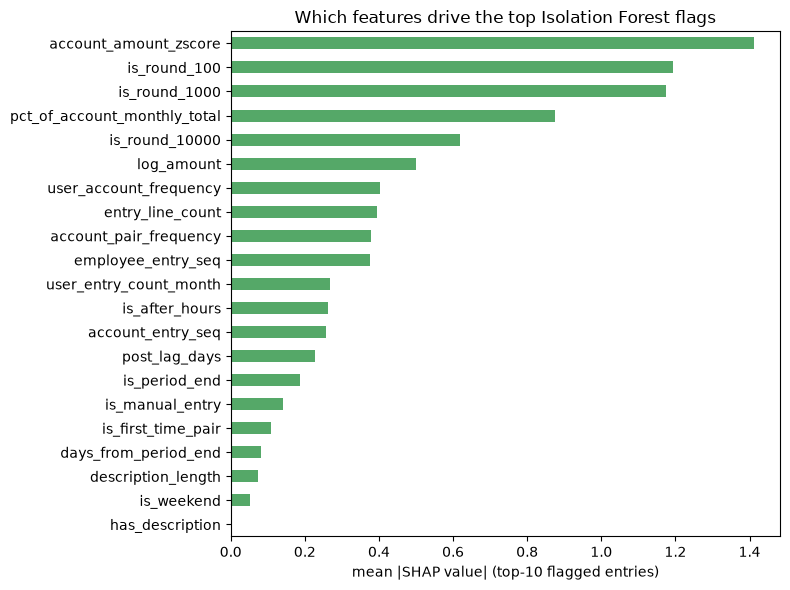

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
mean_abs_shap.sort_values().plot.barh(ax=ax, color="#55A868")
ax.set_xlabel("mean |SHAP value| (top-10 flagged entries)")
ax.set_title("Which features drive the top Isolation Forest flags")
plt.tight_layout()
plt.show()

## 4. Method overlap

Three entry-level flags, all restricted to the same scored population
(`account_entry_seq > 10`):

- **Benford** — an entry's `primary_account_key` belongs to one of the
  accounts that failed the segmented Benford test in Section 1
  (`p < 0.05`, `n >= 50`). This is an account-level signal applied down to
  its entries, not a per-row test — Benford's Law isn't defined for a
  single number.
- **Segmented outlier** — `segmented_outlier_flag` from Section 2
  (within-account z-score or IQR).
- **Isolation Forest** — `isolation_forest_flag` from Section 3.

If these methods were redundant, they'd flag nearly the same entries. If
they're each catching something different — which is the more likely
outcome for three methods built on such different logic — the overlap
should be small.

In [18]:
failing_accounts = set(benford_acct_results.loc[benford_acct_results["p_value"] < 0.05, "account_name"])
acct_key_to_name = acct_digit_df.drop_duplicates("primary_account_key").set_index("primary_account_key")["account_name"]

overlap_df = pd.DataFrame(index=if_df.index)
overlap_df["primary_account_key"] = outlier_df.set_index("header_id")["primary_account_key"].reindex(overlap_df.index)
overlap_df["benford_flag"] = overlap_df["primary_account_key"].map(acct_key_to_name).isin(failing_accounts).fillna(False)
overlap_df["segmented_outlier_flag"] = outlier_df.set_index("header_id")["segmented_outlier_flag"].reindex(overlap_df.index).fillna(False)
overlap_df["isolation_forest_flag"] = if_df["isolation_forest_flag"]

methods = ["benford_flag", "segmented_outlier_flag", "isolation_forest_flag"]
print("scored population:", len(overlap_df))
overlap_df[methods].sum()

scored population: 113711


benford_flag              38730
segmented_outlier_flag    10817
isolation_forest_flag      3412
dtype: int64

In [19]:
for i in range(len(methods)):
    for j in range(i + 1, len(methods)):
        m1, m2 = methods[i], methods[j]
        both = (overlap_df[m1] & overlap_df[m2]).sum()
        union = (overlap_df[m1] | overlap_df[m2]).sum()
        jaccard = both / union if union else 0
        print(f"{m1} vs {m2}: both={both}, jaccard={jaccard:.3f}")
        print(pd.crosstab(overlap_df[m1], overlap_df[m2]), "\n")

benford_flag vs segmented_outlier_flag: both=3181, jaccard=0.069
segmented_outlier_flag  False  True 
benford_flag                        
False                   67345   7636
True                    35549   3181 

benford_flag vs isolation_forest_flag: both=1725, jaccard=0.043
isolation_forest_flag  False  True 
benford_flag                       
False                  73294   1687
True                   37005   1725 

segmented_outlier_flag vs isolation_forest_flag: both=1607, jaccard=0.127
isolation_forest_flag    False  True 
segmented_outlier_flag               
False                   101089   1805
True                      9210   1607 



0    66726
1    41550
2     4896
3      539
Name: count, dtype: int64


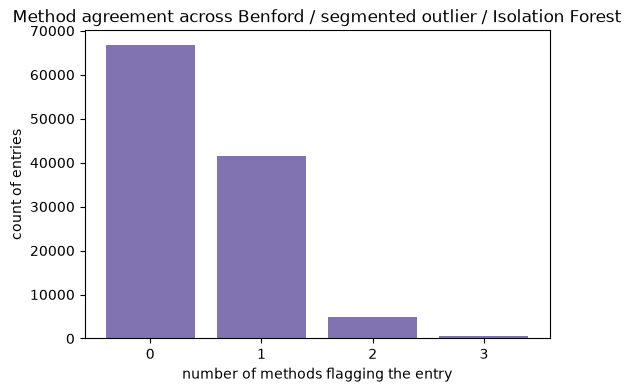

In [20]:
flag_count = overlap_df[methods].sum(axis=1)
counts_by_n_methods = flag_count.value_counts().sort_index()
print(counts_by_n_methods)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts_by_n_methods.index.astype(str), counts_by_n_methods.values, color="#8172B2")
ax.set_xlabel("number of methods flagging the entry")
ax.set_ylabel("count of entries")
ax.set_title("Method agreement across Benford / segmented outlier / Isolation Forest")
plt.show()

**Finding.** Reading `counts_by_n_methods` together with the pairwise
Jaccard scores above: most of the scored population is flagged by zero or
one method, agreement across all three is rare, and each method's flagged
set is dominated by entries none of the others caught. That's expected
given how differently each one works — Benford operates on account-level
digit *distributions*, the segmented rules on a *single account-relative
amount*, and Isolation Forest on the *joint* feature space — and it's the
reason Phase 5 scores 4a and 4b as separate scoreboards against
`ground_truth` rather than blending them into one ranking: a low-overlap
set of weak detectors can still cover more of the error space together
than any one of them would alone, but only if they're evaluated for what
they each actually catch.